# 01 — Limit Order Book (LOB)

## Was ist ein Limit Order Book?

Jede Börse und jeder Market Maker arbeitet mit einem **Limit Order Book (LOB)**. Es ist das Herzstück des modernen Handels.

Das LOB ist eine geordnete Liste aller offenen **Kauf- und Verkaufsorders** für ein Wertpapier:

- **Bid Side** (Kaufseite): Alle Limits bei denen Marktteilnehmer bereit sind zu **kaufen**
- **Ask Side** (Verkaufsseite): Alle Limits bei denen Marktteilnehmer bereit sind zu **verkaufen**

```
ASK SIDE (Verkäufer)
──────────────────────
  101.20  │  500 Stück   ← Bester Ask (lowest ask)
  101.30  │  300 Stück
  101.50  │  800 Stück

  ── SPREAD ──

  101.00  │  400 Stück   ← Bester Bid (highest bid)
  100.90  │  600 Stück
  100.70  │  200 Stück
──────────────────────
BID SIDE (Käufer)
```

### Wichtige Begriffe:
| Begriff | Definition |
|---|---|
| **Best Bid** | Höchster Kaufpreis im Buch |
| **Best Ask** | Niedrigster Verkaufspreis im Buch |
| **Mid Price** | (Best Bid + Best Ask) / 2 |
| **Spread** | Best Ask − Best Bid |
| **Depth** | Volumen auf einem bestimmten Preisniveau |

---
> **Warum ist das für S&T relevant?**  
> Als Trader liest du das Orderbook den ganzen Tag. Du erkennst daran: Wo ist Liquidität? Wo sind große Orders versteckt? Wie aggressiv ist der Market Maker? Wir bauen es jetzt selbst nach.

In [1]:
# Imports — das brauchen wir für dieses Notebook
import numpy as np
import polars as pl          # polars statt pandas — schneller und moderner
import matplotlib.pyplot as plt
from collections import defaultdict

---
## Teil 1: Datenstruktur für ein Order Book

Wie speichern wir ein Orderbook effizient?

Eine einfache Möglichkeit: **Dictionary** mit Preislevel als Key, Volumen als Value.

```python
bids = {101.00: 400, 100.90: 600, 100.70: 200}  # Preis → Volumen
asks = {101.20: 500, 101.30: 300, 101.50: 800}
```

Wir bauen eine saubere **`OrderBook` Klasse** — das ist Python OOP (Object-Oriented Programming) in der Praxis.

> **Python Konzept: Klassen**  
> Eine Klasse ist ein Bauplan für ein Objekt. `OrderBook` ist der Bauplan, `book = OrderBook()` erstellt ein konkretes Buch.

In [2]:
class OrderBook:
    """
    Einfaches Limit Order Book.
    
    Speichert Bid und Ask Orders als Dictionaries:
        {preis: volumen}
    """

    def __init__(self):
        # defaultdict(float) → gibt 0.0 zurück wenn ein Key nicht existiert
        # Das verhindert KeyErrors beim Updaten von Levels
        self.bids = defaultdict(float)  # Kauforders: höherer Preis = bessere Order
        self.asks = defaultdict(float)  # Verkaufsorders: niedrigerer Preis = bessere Order

    # --- Orders hinzufügen / updaten ---

    def add_bid(self, price: float, volume: float):
        """Fügt Volumen auf einem Bid-Level hinzu."""
        self.bids[price] += volume

    def add_ask(self, price: float, volume: float):
        """Fügt Volumen auf einem Ask-Level hinzu."""
        self.asks[price] += volume

    def remove_bid(self, price: float):
        """Entfernt ein komplettes Bid-Level."""
        if price in self.bids:
            del self.bids[price]

    def remove_ask(self, price: float):
        """Entfernt ein komplettes Ask-Level."""
        if price in self.asks:
            del self.asks[price]

    # --- Wichtige Kennzahlen ---

    @property
    def best_bid(self) -> float:
        """Bester (höchster) Kaufpreis."""
        return max(self.bids.keys()) if self.bids else None

    @property
    def best_ask(self) -> float:
        """Bester (niedrigster) Verkaufspreis."""
        return min(self.asks.keys()) if self.asks else None

    @property
    def mid_price(self) -> float:
        """Mittelpunkt zwischen Best Bid und Best Ask."""
        if self.best_bid and self.best_ask:
            return (self.best_bid + self.best_ask) / 2
        return None

    @property
    def spread(self) -> float:
        """Absoluter Spread in Preis-Einheiten."""
        if self.best_bid and self.best_ask:
            return self.best_ask - self.best_bid
        return None

    @property
    def spread_bps(self) -> float:
        """Spread in Basispunkten (bps). 1 bps = 0.01%
        
        Formel: (Spread / Mid Price) * 10_000
        Das ist die Standardmessung im Trading — unabhängig vom Preisniveau.
        """
        if self.spread and self.mid_price:
            return (self.spread / self.mid_price) * 10_000
        return None

    # --- Darstellung ---

    def __repr__(self) -> str:
        """Gibt eine lesbare Zusammenfassung des Buches zurück."""
        return (
            f"OrderBook | "
            f"Best Bid: {self.best_bid:.2f} | "
            f"Best Ask: {self.best_ask:.2f} | "
            f"Mid: {self.mid_price:.2f} | "
            f"Spread: {self.spread:.4f} ({self.spread_bps:.1f} bps)"
        )

print("Klasse OrderBook definiert.")

Klasse OrderBook definiert.


---
## Teil 2: Ein Order Book befüllen

Wir simulieren ein realistisches Buch für eine Aktie bei ~100€.

In [3]:
# Order Book erstellen und befüllen
book = OrderBook()

# --- Bid Side (Käufer) ---
# Konvention: Beste Bids zuerst (höchster Preis)
book.add_bid(100.00, 400)  # Best Bid
book.add_bid(99.90,  600)
book.add_bid(99.80,  250)
book.add_bid(99.70,  800)
book.add_bid(99.50,  1200)

# --- Ask Side (Verkäufer) ---
# Konvention: Beste Asks zuerst (niedrigster Preis)
book.add_ask(100.20, 500)  # Best Ask
book.add_ask(100.30, 300)
book.add_ask(100.40, 450)
book.add_ask(100.60, 700)
book.add_ask(100.80, 1000)

# Zusammenfassung ausgeben
print(book)
print()
print(f"Best Bid Volume:  {book.bids[book.best_bid]:.0f} Stück")
print(f"Best Ask Volume:  {book.asks[book.best_ask]:.0f} Stück")

OrderBook | Best Bid: 100.00 | Best Ask: 100.20 | Mid: 100.10 | Spread: 0.2000 (20.0 bps)

Best Bid Volume:  400 Stück
Best Ask Volume:  500 Stück


---
## Teil 3: Das Buch als DataFrame darstellen

Im echten Trading siehst du das Orderbook als Tabelle auf deinem Terminal.

> **Python Konzept: DataFrames (mit Polars)**  
> Ein `DataFrame` ist eine Tabelle mit benannten Spalten — die wichtigste Datenstruktur für Quants.  
> **Polars** ist die moderne Alternative zu Pandas: geschrieben in Rust, deutlich schneller bei großen Datenmengen, und hat eine klarere, fehlerresistentere Syntax.
>
> Wichtigster Unterschied zu Pandas:  
> Polars hat **keinen Index**. Jede Spalte ist gleichwertig — das macht den Code sauberer.

In [4]:
def book_to_dataframe(book: OrderBook, levels: int = 5) -> pl.DataFrame:
    """
    Konvertiert das OrderBook in einen lesbaren Polars DataFrame.

    Args:
        book:   Das OrderBook Objekt
        levels: Anzahl der Preislevels die angezeigt werden

    Returns:
        pl.DataFrame mit Ask-Seite oben, Bid-Seite unten

    Polars Konzept:
        pl.DataFrame() nimmt eine Liste von Dictionaries entgegen.
        Jedes Dictionary = eine Zeile. Die Keys werden zu Spaltennamen.
    """
    # Asks: sortiert aufsteigend (beste = niedrigste zuerst)
    ask_prices = sorted(book.asks.keys())[:levels]
    ask_rows = [
        {
            "side":            "ASK",
            "price":           p,
            "volume":          book.asks[p],
            "cumulative_vol":  sum(book.asks[q] for q in ask_prices if q <= p),
        }
        for p in ask_prices
    ]

    # Bids: sortiert absteigend (beste = höchste zuerst)
    bid_prices = sorted(book.bids.keys(), reverse=True)[:levels]
    bid_rows = [
        {
            "side":            "BID",
            "price":           p,
            "volume":          book.bids[p],
            "cumulative_vol":  sum(book.bids[q] for q in bid_prices if q >= p),
        }
        for p in bid_prices
    ]

    # Asks umkehren → teuerste Ask oben, beste Ask direkt über dem Spread
    rows = ask_rows[::-1] + bid_rows

    # pl.DataFrame() aus Liste von Dicts erstellen
    df = pl.DataFrame(rows)

    # Datentypen explizit setzen — in Polars ist das explizit und transparent
    df = df.with_columns([
        pl.col("price").cast(pl.Float64),
        pl.col("volume").cast(pl.Float64),
        pl.col("cumulative_vol").cast(pl.Float64),
    ])

    return df


df = book_to_dataframe(book)

# Polars zeigt DataFrames in Jupyter direkt als schöne Tabelle an
print("=== Order Book (Polars DataFrame) ===")
print(df)

=== Order Book (Polars DataFrame) ===
shape: (10, 4)
┌──────┬───────┬────────┬────────────────┐
│ side ┆ price ┆ volume ┆ cumulative_vol │
│ ---  ┆ ---   ┆ ---    ┆ ---            │
│ str  ┆ f64   ┆ f64    ┆ f64            │
╞══════╪═══════╪════════╪════════════════╡
│ ASK  ┆ 100.8 ┆ 1000.0 ┆ 2950.0         │
│ ASK  ┆ 100.6 ┆ 700.0  ┆ 1950.0         │
│ ASK  ┆ 100.4 ┆ 450.0  ┆ 1250.0         │
│ ASK  ┆ 100.3 ┆ 300.0  ┆ 800.0          │
│ ASK  ┆ 100.2 ┆ 500.0  ┆ 500.0          │
│ BID  ┆ 100.0 ┆ 400.0  ┆ 400.0          │
│ BID  ┆ 99.9  ┆ 600.0  ┆ 1000.0         │
│ BID  ┆ 99.8  ┆ 250.0  ┆ 1250.0         │
│ BID  ┆ 99.7  ┆ 800.0  ┆ 2050.0         │
│ BID  ┆ 99.5  ┆ 1200.0 ┆ 3250.0         │
└──────┴───────┴────────┴────────────────┘


---
## Teil 4: Market Order Execution — Was passiert wenn jemand kauft?

Eine **Market Order** ist eine Order ohne Preislimit: "Kaufe 700 Stück sofort zum besten verfügbaren Preis".

Das nennt man **Walking the Book** — die Order frisst sich durch die Ask-Levels:

```
Kaufe 700 Stück:
  Level 100.20 → 500 verfügbar → kaufe alle 500  (500 verbraucht, 200 noch offen)
  Level 100.30 → 300 verfügbar → kaufe 200       (fertig)

Durchschnittspreis (VWAP): (500*100.20 + 200*100.30) / 700 = 100.229
```

Der Unterschied zwischen dem **Mid Price** und dem tatsächlich bezahlten Preis = **Market Impact**.

In [5]:
def execute_market_buy(book: OrderBook, quantity: float) -> dict:
    """
    Simuliert eine Market Buy Order gegen das Order Book.
    
    Args:
        book:     Das OrderBook (wird verändert!)
        quantity: Anzahl der zu kaufenden Stücke
    
    Returns:
        dict mit Ausführungsdetails
    """
    remaining  = quantity
    fills      = []       # Liste der einzelnen Ausführungen
    total_cost = 0.0

    # Asks sortiert: günstigste zuerst
    ask_levels = sorted(book.asks.keys())

    for price in ask_levels:
        if remaining <= 0:
            break

        available = book.asks[price]
        filled    = min(remaining, available)  # Kann nicht mehr kaufen als verfügbar

        fills.append({"price": price, "volume": filled})
        total_cost += filled * price
        remaining  -= filled

        # Buch updaten
        if filled == available:
            book.remove_ask(price)   # Level komplett verbraucht
        else:
            book.asks[price] -= filled  # Level teilweise verbraucht

    filled_qty = quantity - remaining
    vwap       = total_cost / filled_qty if filled_qty > 0 else 0

    return {
        "requested":    quantity,
        "filled":       filled_qty,
        "unfilled":     remaining,
        "vwap":         vwap,
        "fills":        fills,
        "total_cost":   total_cost,
    }


# --- Test: Kaufe 700 Stück ---
mid_before = book.mid_price
result     = execute_market_buy(book, quantity=700)

print("=" * 45)
print("MARKET BUY — Ausführung")
print("=" * 45)
print(f"Angefordert:      {result['requested']:.0f} Stück")
print(f"Ausgeführt:       {result['filled']:.0f} Stück")
print(f"Nicht ausgeführt: {result['unfilled']:.0f} Stück")
print()
print("Einzelne Fills:")
for fill in result["fills"]:
    print(f"  {fill['volume']:.0f} @ {fill['price']:.2f}")
print()
print(f"VWAP:             {result['vwap']:.4f}")
print(f"Mid Price vorher: {mid_before:.4f}")
print(f"Market Impact:    {result['vwap'] - mid_before:.4f} ({(result['vwap']/mid_before - 1)*10000:.1f} bps)")
print()
print("Buch nach der Order:")
print(book)

MARKET BUY — Ausführung
Angefordert:      700 Stück
Ausgeführt:       700 Stück
Nicht ausgeführt: 0 Stück

Einzelne Fills:
  500 @ 100.20
  200 @ 100.30

VWAP:             100.2286
Mid Price vorher: 100.1000
Market Impact:    0.1286 (12.8 bps)

Buch nach der Order:
OrderBook | Best Bid: 100.00 | Best Ask: 100.30 | Mid: 100.15 | Spread: 0.3000 (30.0 bps)


---
## Teil 5: Orderbook Visualisierung — Market Depth Chart

Der **Market Depth Chart** zeigt das kumulierte Volumen über alle Preislevels.
Du siehst sofort: Wo ist eine "Wand" an Liquidität? Wo ist das Buch dünn?

> Im Trading nennt man große Orders die versteckt oder geteilt platziert werden **Iceberg Orders**.
> Ein dünnes Buch mit plötzlich großem Volumen bei einem Level = verdächtig.

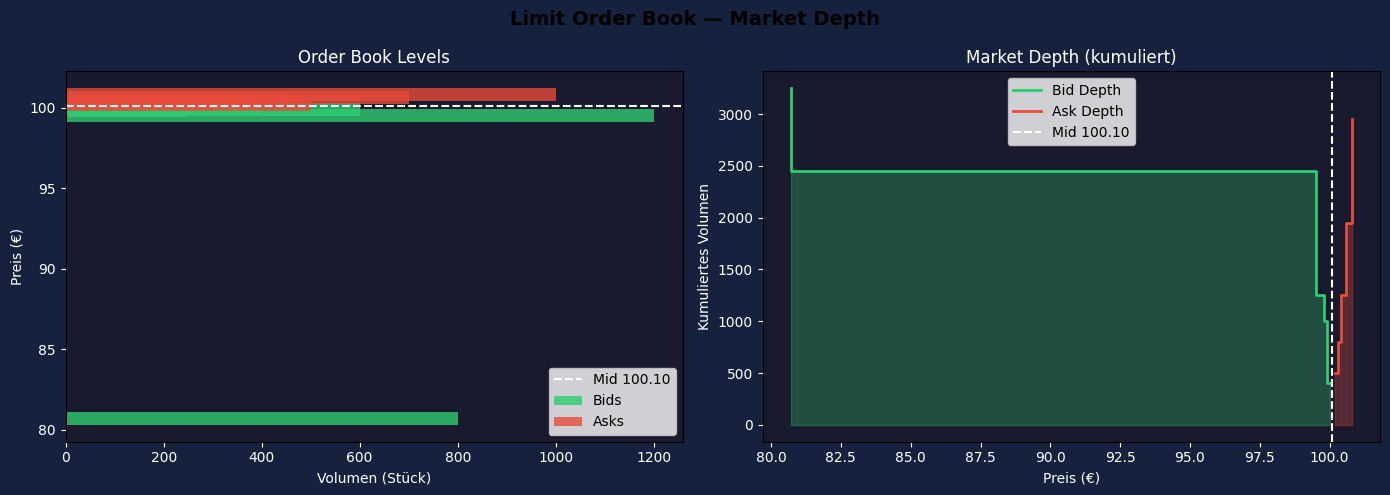

Chart gespeichert: data/orderbook_depth.png


In [ ]:
# Frisches Buch für die Visualisierung
book_viz = OrderBook()

book_viz.add_bid(100.00, 400)
book_viz.add_bid(99.90,  600)
book_viz.add_bid(99.80,  250)
book_viz.add_bid(99.70,  800)
book_viz.add_bid(99.50,  1200)

book_viz.add_ask(100.20, 500)
book_viz.add_ask(100.30, 300)
book_viz.add_ask(100.40, 450)
book_viz.add_ask(100.60, 700)
book_viz.add_ask(100.80, 1000)

# --- Kumuliertes Volumen berechnen ---

bid_prices = sorted(book_viz.bids.keys(), reverse=True)
bid_cum    = np.cumsum([book_viz.bids[p] for p in bid_prices])

ask_prices = sorted(book_viz.asks.keys())
ask_cum    = np.cumsum([book_viz.asks[p] for p in ask_prices])

# --- Plot ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Limit Order Book — Market Depth", fontsize=14, fontweight="bold")

# --- Links: Barplot (klassische LOB Ansicht) ---
ax1 = axes[0]

bid_vols = [book_viz.bids[p] for p in bid_prices]
ask_vols = [book_viz.asks[p] for p in ask_prices]

ax1.barh(bid_prices, bid_vols, color="#2ecc71", alpha=0.8, label="Bids")
ax1.barh(ask_prices, ask_vols, color="#e74c3c", alpha=0.8, label="Asks")
ax1.axhline(book_viz.mid_price, color="white", linestyle="--", linewidth=1.5, label=f"Mid {book_viz.mid_price:.2f}")
ax1.set_xlabel("Volumen (Stück)")
ax1.set_ylabel("Preis (€)")
ax1.set_title("Order Book Levels")
ax1.legend()
ax1.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#16213e")
ax1.tick_params(colors="white")
ax1.xaxis.label.set_color("white")
ax1.yaxis.label.set_color("white")
ax1.title.set_color("white")

# --- Rechts: Kumulierter Depth Chart ---
ax2 = axes[1]

ax2.step(bid_prices, bid_cum, where="post", color="#2ecc71", linewidth=2, label="Bid Depth")
ax2.fill_between(bid_prices, bid_cum, step="post", alpha=0.3, color="#2ecc71")

ax2.step(ask_prices, ask_cum, where="post", color="#e74c3c", linewidth=2, label="Ask Depth")
ax2.fill_between(ask_prices, ask_cum, step="post", alpha=0.3, color="#e74c3c")

ax2.axvline(book_viz.mid_price, color="white", linestyle="--", linewidth=1.5, label=f"Mid {book_viz.mid_price:.2f}")
ax2.set_xlabel("Preis (€)")
ax2.set_ylabel("Kumuliertes Volumen")
ax2.set_title("Market Depth (kumuliert)")
ax2.legend()
ax2.set_facecolor("#1a1a2e")
ax2.tick_params(colors="white")
ax2.xaxis.label.set_color("white")
ax2.yaxis.label.set_color("white")
ax2.title.set_color("white")

plt.tight_layout()
plt.savefig("../data/orderbook_depth.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Chart gespeichert: data/orderbook_depth.png")

---
## Teil 6: Spread Analyse — Warum existiert ein Spread?

Der Spread ist **die Vergütung des Market Makers** für das Stellen von Liquidität.
Er kompensiert drei Risiken:

| Komponente | Beschreibung |
|---|---|
| **Inventory Risk** | Der MM hält nach dem Trade eine ungewollte Position |
| **Adverse Selection** | Der Gegenpart weiß möglicherweise mehr (Informed Trader) |
| **Order Processing Costs** | Operative Kosten für das Stellen von Quotes |

**Faustregel für S&T Interviews:**
> *"Der Spread ist eng wenn Liquidität hoch ist und Volatilität niedrig ist.  
> Der Spread ist weit wenn Liquidität niedrig ist oder Volatilität hoch ist."*

Wir visualisieren das jetzt:

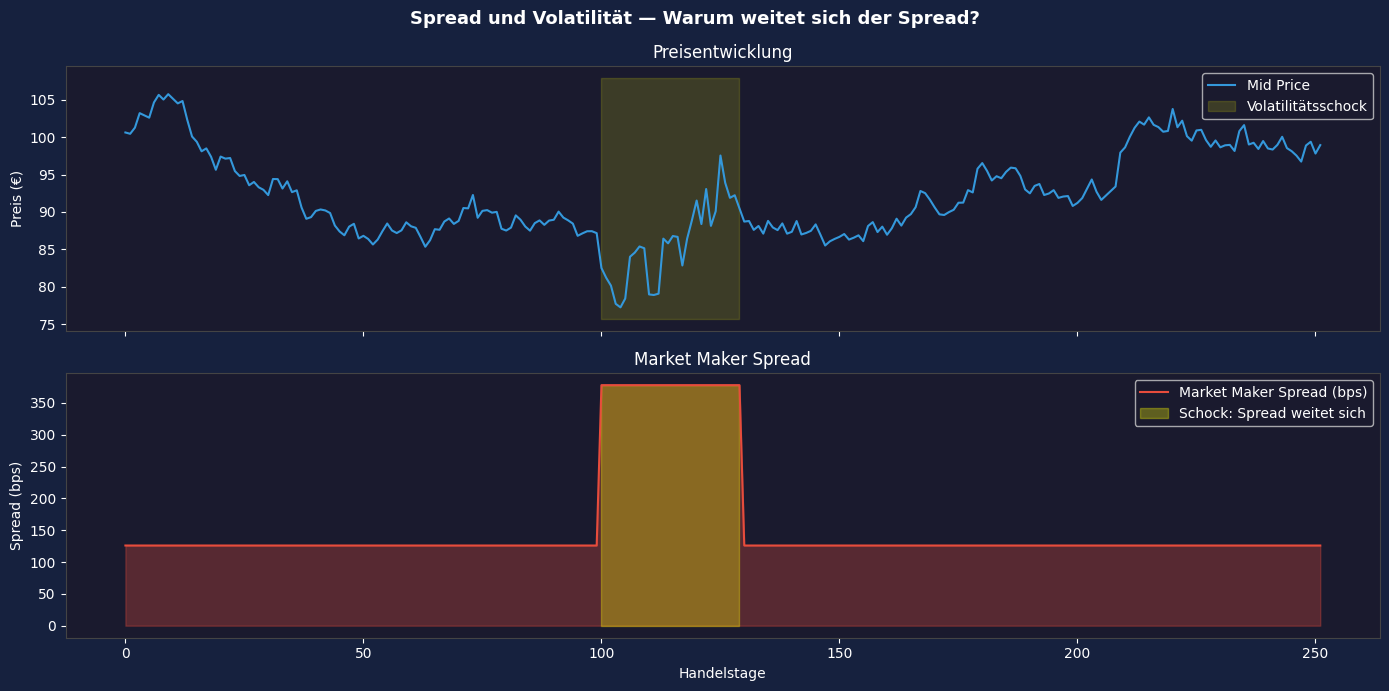

Normaler Spread:          126.0 bps
Spread im Schock:         378.0 bps
Spread-Ausweitung Faktor: 3.0x


In [7]:
# Simuliere: Wie verändert sich der Spread mit der Volatilität?

# Annahme: Ein Market Maker stellt einen Spread proportional zur erwarteten Volatilität
# Einfaches Modell: Spread ≈ k * σ (Volatilität)

np.random.seed(42)

# Simuliere 252 Handelstage (1 Jahr)
n_days      = 252
mid_price   = 100.0
k           = 0.5   # Spread-Koeffizient des Market Makers

# Simuliere Volatilität: ruhige Phase → Schock → ruhige Phase
base_vol  = 0.20                               # 20% annualisiert
daily_vol = base_vol / np.sqrt(252)            # Tägliche Volatilität

# Volatilitätsregime: Normalphase + Schock in der Mitte
vols = np.ones(n_days) * daily_vol
vols[100:130] *= 3.0  # Volatilitätsschock für 30 Tage (z.B. Earnings, Krise)

# Preispfad simulieren (Geometric Brownian Motion, vereinfacht)
returns     = np.random.normal(0, vols)
price_path  = mid_price * np.cumprod(1 + returns)

# Spread des Market Makers (proportional zur realisierten Volatilität)
spreads_bps = k * vols * 10_000 * 2  # in Basispunkten

days = np.arange(n_days)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Spread und Volatilität — Warum weitet sich der Spread?", fontsize=13, fontweight="bold", color="white")
fig.patch.set_facecolor("#16213e")

for ax in [ax1, ax2]:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

# Preispfad
ax1.plot(days, price_path, color="#3498db", linewidth=1.5, label="Mid Price")
ax1.fill_between(days[100:130], price_path.min()*0.98, price_path.max()*1.02,
                  alpha=0.15, color="yellow", label="Volatilitätsschock")
ax1.set_ylabel("Preis (€)")
ax1.set_title("Preisentwicklung")
ax1.legend(facecolor="#1a1a2e", labelcolor="white")

# Spread
ax2.plot(days, spreads_bps, color="#e74c3c", linewidth=1.5, label="Market Maker Spread (bps)")
ax2.fill_between(days, spreads_bps, alpha=0.3, color="#e74c3c")
ax2.fill_between(days[100:130], 0, spreads_bps[100:130],
                  alpha=0.3, color="yellow", label="Schock: Spread weitet sich")
ax2.set_ylabel("Spread (bps)")
ax2.set_xlabel("Handelstage")
ax2.set_title("Market Maker Spread")
ax2.legend(facecolor="#1a1a2e", labelcolor="white")

plt.tight_layout()
plt.savefig("../data/spread_volatility.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"Normaler Spread:          {spreads_bps[:100].mean():.1f} bps")
print(f"Spread im Schock:         {spreads_bps[100:130].mean():.1f} bps")
print(f"Spread-Ausweitung Faktor: {spreads_bps[100:130].mean()/spreads_bps[:100].mean():.1f}x")

---
## Zusammenfassung & Key Takeaways

### Was du in diesem Notebook gelernt hast:

**Market Microstructure:**
- Das LOB ist die Basis aller modernen Märkte
- Best Bid / Best Ask / Mid Price / Spread sind die fundamentalen Begriffe
- Market Orders "walken das Buch" → Market Impact entsteht
- Der Spread kompensiert: Inventory Risk + Adverse Selection + Kosten
- Spread weitet sich mit steigender Volatilität

**Python Konzepte:**
- Klassen (`class`) und Methoden (`def`)
- Properties (`@property`) für berechnete Attribute
- `defaultdict` für sichere Dictionary-Operationen
- `polars.DataFrame` für tabellarische Daten — moderner und schneller als pandas
- `pl.col()` und `.with_columns()` für Spaltenoperationen in Polars
- `matplotlib` für Visualisierungen
- `numpy` für numerische Berechnungen

---

### Interview-Fragen die du jetzt beantworten kannst:

❓ *"Was ist der Unterschied zwischen einer Market Order und einer Limit Order?"*  
❓ *"Warum stellt ein Market Maker überhaupt einen Spread?"*  
❓ *"Was passiert mit dem Spread wenn die Volatilität steigt?"*  
❓ *"Was bedeutet Market Impact?"*  

---

### Nächste Schritte:
- **`02_market_microstructure`**: Adverse Selection — wann verliert der Market Maker Geld?
- **`02_derivatives_pricing`**: Black-Scholes und die Greeks

> *"Understanding the order book is understanding how prices are actually formed — not in theory, but in practice."*